In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:
file_path = "../data/load_data.csv"

In [24]:
vals = []
cols = []
with open(file_path, "r") as f:
    lines = f.readlines()

    for l in lines:
        l = l.strip()
        if not cols:
            cols = l.split(",")
        else:
            vals.append(l.split(","))

df = pd.DataFrame(vals, columns=cols)
df.head()

,A,B,C,D,E
0,1.276,21.400,63.957,216.204,528
1,1.002,21.950,61.697,204.484,514
2,1.114,22.454,63.522,205.608,514
3,1.133,22.494,61.590,206.565,501
4,0.845,21.654,63.729,201.289,532


In [ ]:
nd = np.genfromtxt(file_path, delimiter=",", names=True)
nd[:5]
nd["A"][:5]

array([1.276, 1.002, 1.114, 1.133, 0.845])

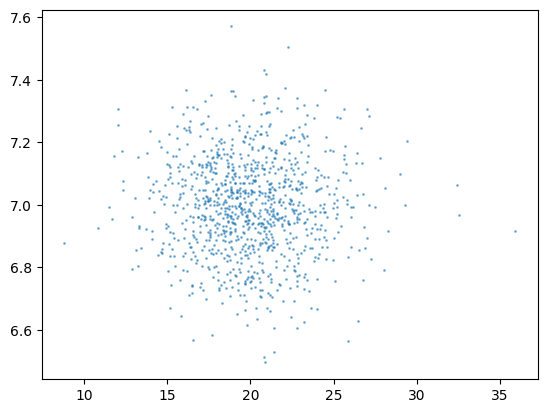

In [ ]:
# Jitter plot to display single dimention on the scater plot 
file_path = "../data/outlier_1d.txt"
nd_1d = np.genfromtxt(file_path)
jitter_std = nd_1d.std() * 0.05
nd_1d_jitter = np.random.normal(7, jitter_std, size=nd_1d.size)
plt.scatter(nd_1d, nd_1d_jitter, s=1, alpha=0.5)

In [40]:
# Outlier detection
# Z-score
threshold = 3
mean = np.mean(nd_1d)
std = np.std(nd_1d)

# These are equivalent:
z_scores = (nd_1d - mean) / std
outliers = np.abs(z_scores) > threshold

Rejection 4 points
z-score of 3 corresponds to a prob of 0.27%


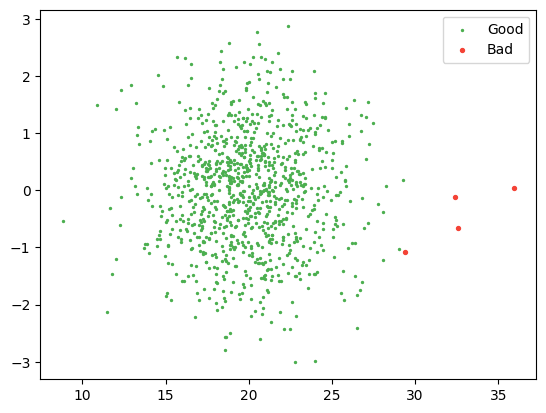

In [42]:
good = z_scores < threshold

print(f"Rejection {(~good).sum()} points")
from scipy.stats import norm

print(f"z-score of 3 corresponds to a prob of {100 * 2 * norm.sf(threshold):0.2f}%")
visual_scatter = np.random.normal(size=nd_1d.size)
plt.scatter(nd_1d[good], visual_scatter[good], s=2, label="Good", color="#4CAF50")
plt.scatter(nd_1d[~good], visual_scatter[~good], s=8, label="Bad", color="#F44336")
plt.legend()